In [1]:
import os
import glob
import h5py
import numpy as np
from skimage.transform import resize
from tqdm import tqdm

# 📁 List of folders (April, May, June–July)
RAW_DIRS = [
    r"D:\INSAT_3DR\Order\Jul25_136513",  # April
    r"D:\INSAT_3DR\Order\Jul25_136405",  # May
    r"D:\INSAT_3DR\Order\Jul25_136257",  # June–July
]

OUT_DIR = r"D:\Processed"
SEQ_IN, SEQ_OUT = 4, 2
TARGET_SHAPE = (400, 400)

os.makedirs(OUT_DIR, exist_ok=True)

# 🔧 Load one HDF file and return normalized 400x400 BT frame
def load_tir1_bt(h5_path):
    with h5py.File(h5_path, 'r') as f:
        dn = f["IMG_TIR1"][0, :, :]
        lookup = f["IMG_TIR1_TEMP"][:]
        bt = lookup[dn]
    return bt.astype(np.float32)

# 🧠 Collect and sort all files from all directories
all_files = []
for raw_dir in RAW_DIRS:
    all_files.extend(glob.glob(os.path.join(raw_dir, "*.h5")))

all_files.sort()  # ensure chronological order across months
print(f"Total .h5 files found: {len(all_files)}")

# 📦 Load and resize all BT frames
frames = []
for path in tqdm(all_files, desc="Loading & resizing"):
    bt = load_tir1_bt(path)
    bt_rs = resize(bt, TARGET_SHAPE, anti_aliasing=True)
    bt_norm = (bt_rs - bt_rs.min()) / (bt_rs.max() - bt_rs.min() + 1e-6)
    frames.append(bt_norm)

frames = np.stack(frames, axis=0)  # (N, H, W)

# 🪄 Create overlapping sequences of (4 ➜ 2)
num_samples = len(frames) - (SEQ_IN + SEQ_OUT) + 1
print(f"Total training samples: {num_samples}")

for i in tqdm(range(num_samples), desc="Creating sequences"):
    inp = frames[i : i + SEQ_IN]       # shape: (4, H, W)
    tgt = frames[i + SEQ_IN : i + SEQ_IN + SEQ_OUT]  # (2, H, W)
    out_path = os.path.join(OUT_DIR, f"sample_{i:05d}.npz")
    np.savez_compressed(out_path, input=inp, target=tgt)

print(f"\n✅ Done. All sequences saved to: {OUT_DIR}")


Total .h5 files found: 4457


Loading & resizing: 100%|██████████| 4457/4457 [14:22<00:00,  5.17it/s]


Total training samples: 4452


Creating sequences: 100%|██████████| 4452/4452 [20:03<00:00,  3.70it/s]


✅ Done. All sequences saved to: D:\Processed


In [4]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Check CUDA availability
print("CUDA available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

# Timestep embedding function
def get_timestep_embedding(timesteps, embedding_dim):
    half_dim = embedding_dim // 2
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device, dtype=torch.float32) * - (np.log(10000) / (half_dim - 1)))
    emb = timesteps[:, None].float() * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if embedding_dim % 2 == 1:
        emb = torch.nn.functional.pad(emb, (0, 1))
    return emb

# Dataset
class CloudDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        inp = data["input"]   # (4, H, W) - 4 past frames
        tgt = data["target"]  # (2, H, W) - 2 future frames
        inp = torch.from_numpy(inp).float()  # (4, H, W)
        tgt = torch.from_numpy(tgt).float()  # (2, H, W)
        return inp, tgt

# UNet with multi-channel, conditional input, and timestep embeddings
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=2, cond_channels=4, base_c=32, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.dc1 = DoubleConv(in_channels + cond_channels + embedding_dim, base_c)
        self.pool = nn.MaxPool2d(2)
        self.dc2 = DoubleConv(base_c, base_c*2)
        self.dc3 = DoubleConv(base_c*2, base_c*4)
        self.up2 = nn.ConvTranspose2d(base_c*4, base_c*2, 2, stride=2)
        self.dc4 = DoubleConv(base_c*4, base_c*2)
        self.up1 = nn.ConvTranspose2d(base_c*2, base_c, 2, stride=2)
        self.dc5 = DoubleConv(base_c*2, base_c)
        self.out = nn.Conv2d(base_c, 2, 1)  # Output 2 future frames

    def forward(self, x, cond, t):
        emb = get_timestep_embedding(t, self.embedding_dim)
        emb = emb.view(-1, self.embedding_dim, 1, 1).expand(-1, -1, x.shape[2], x.shape[3])
        x = torch.cat([x, cond, emb], dim=1)  # Concatenate noisy input, condition, and timestep embedding
        x1 = self.dc1(x)
        x2 = self.dc2(self.pool(x1))
        x3 = self.dc3(self.pool(x2))
        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dc4(x)
        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dc5(x)
        return self.out(x)

# Diffusion Model
class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas = torch.sqrt(self.alphas)
        self.sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a_hat = self.alpha_hat.to(x0.device)[t].reshape(-1, 1, 1, 1)
        return torch.sqrt(a_hat) * x0 + torch.sqrt(1 - a_hat) * noise, noise

    def p_sample(self, model, xt, cond, t):
        t_tensor = torch.full((xt.shape[0],), t, device=xt.device, dtype=torch.long)
        pred_noise = model(xt, cond, t_tensor)
        alpha = self.sqrt_alphas.to(xt.device)[t].reshape(-1, 1, 1, 1)
        alpha_hat = self.alpha_hat.to(xt.device)[t].reshape(-1, 1, 1, 1)
        beta = self.betas.to(xt.device)[t].reshape(-1, 1, 1, 1)
        noise = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
        xt_prev = (xt - (1 - alpha) / torch.sqrt(1 - alpha_hat) * pred_noise) / torch.sqrt(alpha) + torch.sqrt(beta) * noise
        return xt_prev

# Training and Inference
device = "cuda" if torch.cuda.is_available() else "cpu"
data_dir = r"D:\projects\cloudmorphai\processed"

# Create train/validation split
all_files = sorted(glob.glob(f"{data_dir}/*.npz"))
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

train_dataset = CloudDataset(train_files)
val_dataset = CloudDataset(val_files)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

model = UNet(in_channels=2, cond_channels=4, embedding_dim=128).to(device)
diff = Diffusion()
optimizer = Adam(model.parameters(), lr=1e-4)
mse = nn.MSELoss()

# Training
num_epochs = 50
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        inputs, targets = inputs.to(device), targets.to(device)
        t = torch.randint(0, diff.T, (targets.shape[0],), device=device)
        xt, noise = diff.q_sample(targets, t)
        
        pred_noise = model(xt, inputs, t)
        loss = mse(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            inputs, targets = inputs.to(device), targets.to(device)
            t = torch.randint(0, diff.T, (targets.shape[0],), device=device)
            xt, noise = diff.q_sample(targets, t)
            
            pred_noise = model(xt, inputs, t)
            loss = mse(pred_noise, noise)
            val_loss += loss.item()
    
    # Calculate average losses
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved new best model")

# Load best model for inference
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Inference function
def generate_future_frames(model, past_frames, diff, steps=1000):
    xt = torch.randn(past_frames.shape[0], 2, past_frames.shape[2], past_frames.shape[3], device=device)
    for t in reversed(range(steps)):
        xt = diff.p_sample(model, xt, past_frames, t)
    return xt

# Test inference with visualization
with torch.no_grad():
    # Get a batch from validation set
    inputs, targets = next(iter(val_loader))
    inputs, targets = inputs.to(device), targets.to(device)
    future_frames = generate_future_frames(model, inputs, diff)
    
    # Calculate MAE between predicted and actual future frames
    mae = torch.mean(torch.abs(future_frames - targets)).item()
    print(f"Mean Absolute Error (MAE) on validation sample: {mae:.4f}")
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    # Plot input frames (first channel of each frame)
    for i in range(min(4, inputs.shape[1])):  # Plot up to 4 past frames
        plt.subplot(2, 4, i + 1)
        plt.imshow(inputs[0, i].cpu().numpy(), cmap='gray')
        plt.title(f'Input Frame {i+1}')
        plt.axis('off')
    
    # Plot predicted future frames
    for i in range(min(2, future_frames.shape[1])):  # Plot up to 2 future frames
        plt.subplot(2, 4, i + 5)
        plt.imshow(future_frames[0, i].cpu().numpy(), cmap='gray')
        plt.title(f'Predicted Frame {i+1}')
        plt.axis('off')
    
    # Plot actual future frames
    for i in range(min(2, targets.shape[1])):  # Plot up to 2 actual future frames
        plt.subplot(2, 4, i + 7)
        plt.imshow(targets[0, i].cpu().numpy(), cmap='gray')
        plt.title(f'Actual Frame {i+1}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

CUDA available: True
GPU Name: NVIDIA GeForce RTX 2050


Epoch 1/50 [Val]: 100%|██████████| 95/95 [00:49<00:00,  1.92it/s]


Epoch 1/50 - Train Loss: 0.5723, Val Loss: 0.1669
Saved new best model


Epoch 2/50 [Val]: 100%|██████████| 95/95 [00:49<00:00,  1.93it/s]


Epoch 2/50 - Train Loss: 0.1094, Val Loss: 0.0935
Saved new best model


...

Epoch 11/50 - Train Loss: 0.0297, Val Loss: 0.0204
Saved new best model


Epoch 12/50 [Val]: 100%|██████████| 95/95 [00:51<00:00,  1.85it/s]


Epoch 12/50 - Train Loss: 0.0236, Val Loss: 0.0227


Epoch 13/50 [Train]:  99%|█████████▉| 374/378 [06:37<00:04,  1.06s/it]


KeyboardInterrupt: 

CUDA available: True
GPU Name: NVIDIA GeForce RTX 2050


Epoch 1/50 [Val]: 100%|██████████| 317/317 [02:42<00:00,  1.95it/s]


Epoch 1/50 - Train Loss: 0.2423, Val Loss: 0.0640
Saved new best model


Epoch 2/50 [Val]: 100%|██████████| 317/317 [02:24<00:00,  2.19it/s]


Epoch 2/50 - Train Loss: 0.0405, Val Loss: 0.0323
Saved new best model


...

Epoch 19/50 - Train Loss: 0.0141, Val Loss: 0.0137
No improvement in validation loss. Patience counter: 3/5


Epoch 20/50 [Val]: 100%|██████████| 317/317 [02:11<00:00,  2.41it/s]


Epoch 20/50 - Train Loss: 0.0144, Val Loss: 0.0165
No improvement in validation loss. Patience counter: 4/5


Epoch 21/50 [Val]: 100%|██████████| 317/317 [02:17<00:00,  2.31it/s]
C:\Users\user\AppData\Local\Temp\ipykernel_18200\106612462.py:186: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental fe

Epoch 21/50 - Train Loss: 0.0124, Val Loss: 0.0144
No improvement in validation loss. Patience counter: 5/5
Early stopping triggered after 21 epochs
Mean Absolute Error (MAE) on validation sample: 0.5263


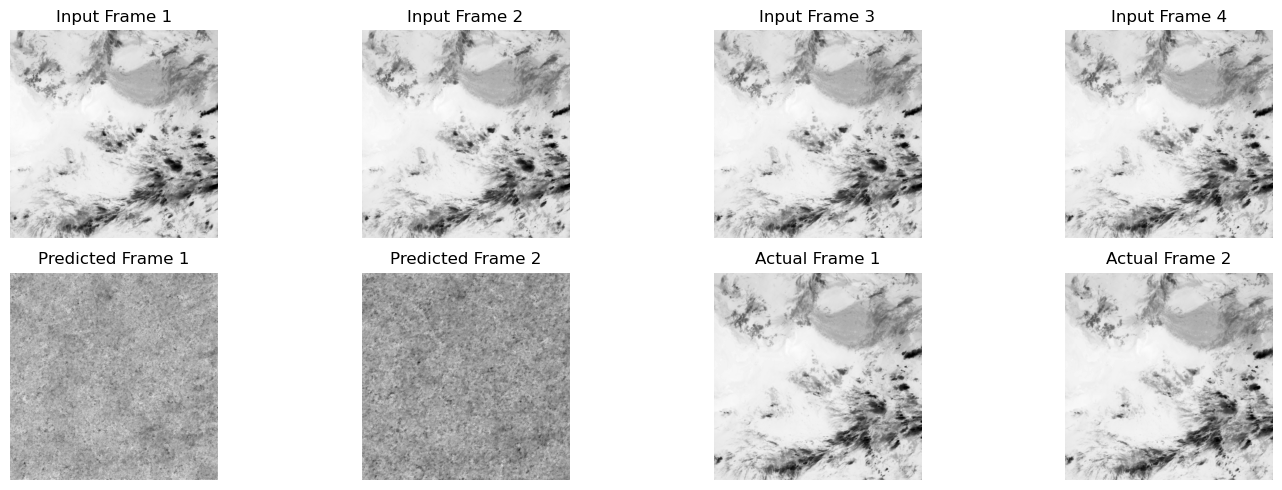

In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Check CUDA availability
print("CUDA available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

# Timestep embedding function
def get_timestep_embedding(timesteps, embedding_dim):
    half_dim = embedding_dim // 2
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device, dtype=torch.float32) * - (np.log(10000) / (half_dim - 1)))
    emb = timesteps[:, None].float() * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if embedding_dim % 2 == 1:
        emb = torch.nn.functional.pad(emb, (0, 1))
    return emb

# Dataset
class CloudDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        inp = data["input"]   # (4, H, W) - 4 past frames
        tgt = data["target"]  # (2, H, W) - 2 future frames
        inp = torch.from_numpy(inp).float()  # (4, H, W)
        tgt = torch.from_numpy(tgt).float()  # (2, H, W)
        return inp, tgt

# UNet with multi-channel, conditional input, and timestep embeddings
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=2, cond_channels=4, base_c=32, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.dc1 = DoubleConv(in_channels + cond_channels + embedding_dim, base_c)
        self.pool = nn.MaxPool2d(2)
        self.dc2 = DoubleConv(base_c, base_c*2)
        self.dc3 = DoubleConv(base_c*2, base_c*4)
        self.up2 = nn.ConvTranspose2d(base_c*4, base_c*2, 2, stride=2)
        self.dc4 = DoubleConv(base_c*4, base_c*2)
        self.up1 = nn.ConvTranspose2d(base_c*2, base_c, 2, stride=2)
        self.dc5 = DoubleConv(base_c*2, base_c)
        self.out = nn.Conv2d(base_c, 2, 1)  # Output 2 future frames

    def forward(self, x, cond, t):
        emb = get_timestep_embedding(t, self.embedding_dim)
        emb = emb.view(-1, self.embedding_dim, 1, 1).expand(-1, -1, x.shape[2], x.shape[3])
        x = torch.cat([x, cond, emb], dim=1)  # Concatenate noisy input, condition, and timestep embedding
        x1 = self.dc1(x)
        x2 = self.dc2(self.pool(x1))
        x3 = self.dc3(self.pool(x2))
        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dc4(x)
        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dc5(x)
        return self.out(x)

# Diffusion Model
class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas = torch.sqrt(self.alphas)
        self.sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a_hat = self.alpha_hat.to(x0.device)[t].reshape(-1, 1, 1, 1)
        return torch.sqrt(a_hat) * x0 + torch.sqrt(1 - a_hat) * noise, noise

    def p_sample(self, model, xt, cond, t):
        t_tensor = torch.full((xt.shape[0],), t, device=xt.device, dtype=torch.long)
        pred_noise = model(xt, cond, t_tensor)
        alpha = self.sqrt_alphas.to(xt.device)[t].reshape(-1, 1, 1, 1)
        alpha_hat = self.alpha_hat.to(xt.device)[t].reshape(-1, 1, 1, 1)
        beta = self.betas.to(xt.device)[t].reshape(-1, 1, 1, 1)
        noise = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
        xt_prev = (xt - (1 - alpha) / torch.sqrt(1 - alpha_hat) * pred_noise) / torch.sqrt(alpha) + torch.sqrt(beta) * noise
        return xt_prev

# Training and Inference
device = "cuda" if torch.cuda.is_available() else "cpu"
data_dir = r"D:\projects\cloudmorphai\Processed"

# Create train/validation split
all_files = sorted(glob.glob(f"{data_dir}/*.npz"))
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

train_dataset = CloudDataset(train_files)
val_dataset = CloudDataset(val_files)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

model = UNet(in_channels=2, cond_channels=4, embedding_dim=128).to(device)
diff = Diffusion()
optimizer = Adam(model.parameters(), lr=1e-4)
mse = nn.MSELoss()

# Training with early stopping
num_epochs = 50
best_val_loss = float('inf')
patience = 5  # Number of epochs to wait before stopping if no improvement
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        inputs, targets = inputs.to(device), targets.to(device)
        t = torch.randint(0, diff.T, (targets.shape[0],), device=device)
        xt, noise = diff.q_sample(targets, t)
        
        pred_noise = model(xt, inputs, t)
        loss = mse(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            inputs, targets = inputs.to(device), targets.to(device)
            t = torch.randint(0, diff.T, (targets.shape[0],), device=device)
            xt, noise = diff.q_sample(targets, t)
            
            pred_noise = model(xt, inputs, t)
            loss = mse(pred_noise, noise)
            val_loss += loss.item()
    
    # Calculate average losses
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved new best model")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"No improvement in validation loss. Patience counter: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            model.load_state_dict(best_model_state)
            break

# Load best model for inference
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Inference function
def generate_future_frames(model, past_frames, diff, steps=1000):
    xt = torch.randn(past_frames.shape[0], 2, past_frames.shape[2], past_frames.shape[3], device=device)
    for t in reversed(range(steps)):
        xt = diff.p_sample(model, xt, past_frames, t)
    return xt

# Test inference with visualization
with torch.no_grad():
    # Get a batch from validation set
    inputs, targets = next(iter(val_loader))
    inputs, targets = inputs.to(device), targets.to(device)
    future_frames = generate_future_frames(model, inputs, diff)
    
    # Calculate MAE between predicted and actual future frames
    mae = torch.mean(torch.abs(future_frames - targets)).item()
    print(f"Mean Absolute Error (MAE) on validation sample: {mae:.4f}")
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    # Plot input frames (first channel of each frame)
    for i in range(min(4, inputs.shape[1])):  # Plot up to 4 past frames
        plt.subplot(2, 4, i + 1)
        plt.imshow(inputs[0, i].cpu().numpy(), cmap='gray')
        plt.title(f'Input Frame {i+1}')
        plt.axis('off')
    
    # Plot predicted future frames
    for i in range(min(2, future_frames.shape[1])):  # Plot up to 2 future frames
        plt.subplot(2, 4, i + 5)
        plt.imshow(future_frames[0, i].cpu().numpy(), cmap='gray')
        plt.title(f'Predicted Frame {i+1}')
        plt.axis('off')
    
    # Plot actual future frames
    for i in range(min(2, targets.shape[1])):  # Plot up to 2 actual future frames
        plt.subplot(2, 4, i + 7)
        plt.imshow(targets[0, i].cpu().numpy(), cmap='gray')
        plt.title(f'Actual Frame {i+1}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [2]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Check CUDA availability
print("CUDA available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

# Timestep embedding function
def get_timestep_embedding(timesteps, embedding_dim):
    half_dim = embedding_dim // 2
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device, dtype=torch.float32) * -(np.log(10000) / (half_dim - 1)))
    emb = timesteps[:, None].float() * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if embedding_dim % 2 == 1:
        emb = torch.nn.functional.pad(emb, (0, 1))
    return emb

# Dataset with normalization
class CloudDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        inp = data["input"]  # (4,H,W)
        tgt = data["target"] # (2,H,W)
        inp = torch.from_numpy(inp).float() / 255.0
        tgt = torch.from_numpy(tgt).float() / 255.0
        return inp, tgt

# Double conv block
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

# UNet predicting x0
class UNet(nn.Module):
    def __init__(self, in_channels=2, cond_channels=4, base_c=32, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.dc1 = DoubleConv(in_channels + cond_channels + embedding_dim, base_c)
        self.pool = nn.MaxPool2d(2)
        self.dc2 = DoubleConv(base_c, base_c*2)
        self.dc3 = DoubleConv(base_c*2, base_c*4)
        self.up2 = nn.ConvTranspose2d(base_c*4, base_c*2, 2, stride=2)
        self.dc4 = DoubleConv(base_c*4, base_c*2)
        self.up1 = nn.ConvTranspose2d(base_c*2, base_c, 2, stride=2)
        self.dc5 = DoubleConv(base_c*2, base_c)
        self.out = nn.Conv2d(base_c, 2, 1)  # predicting x0 channels

    def forward(self, x, cond, t):
        emb = get_timestep_embedding(t, self.embedding_dim)
        emb = emb.view(-1, self.embedding_dim, 1, 1).expand(-1, -1, x.shape[2], x.shape[3])
        x = torch.cat([x, cond, emb], dim=1)
        x1 = self.dc1(x)
        x2 = self.dc2(self.pool(x1))
        x3 = self.dc3(self.pool(x2))
        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dc4(x)
        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dc5(x)
        return self.out(x)

# Diffusion model with x0 parameterization
class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas = torch.sqrt(self.alphas)
        self.sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a_hat = self.alpha_hat.to(x0.device)[t].view(-1,1,1,1)
        return torch.sqrt(a_hat)*x0 + torch.sqrt(1-a_hat)*noise, noise

    def p_sample(self, model, xt, cond, t):
        # model predicts x0 at timestep t
        t_tensor = torch.full((xt.shape[0],), t, device=xt.device, dtype=torch.long)
        x0_pred = model(xt, cond, t_tensor)
        alpha = self.alphas.to(xt.device)[t].view(-1,1,1,1)
        alpha_hat = self.alpha_hat.to(xt.device)[t].view(-1,1,1,1)
        beta = self.betas.to(xt.device)[t].view(-1,1,1,1)
        noise = torch.randn_like(xt) if t>0 else torch.zeros_like(xt)
        # posterior mean
        coef = (xt - (1-alpha)/torch.sqrt(1-alpha_hat)*x0_pred)/torch.sqrt(alpha)
        xt_prev = coef + torch.sqrt(beta)*noise
        return xt_prev

# Setup
device = "cuda" if torch.cuda.is_available() else "cpu"
data_dir = r"D:\Processed"
all_files = sorted(glob.glob(f"{data_dir}/*.npz"))
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)
train_loader = DataLoader(CloudDataset(train_files), batch_size=4, shuffle=True)
val_loader   = DataLoader(CloudDataset(val_files), batch_size=4, shuffle=False)

model = UNet().to(device)
diff = Diffusion()
optimizer = Adam(model.parameters(), lr=1e-4)
mse = nn.MSELoss()

# Training loop (predict x0)
num_epochs = 50; best_val = float('inf'); patience, pc = 5,0
for epoch in range(num_epochs):
    model.train()
    tloss=0
    for inp, tgt in tqdm(train_loader, desc=f"Train {epoch+1}"):
        inp,tgt=inp.to(device),tgt.to(device)
        t = torch.randint(0,diff.T,(tgt.shape[0],),device=device)
        xt,_ = diff.q_sample(tgt,t)
        x0_pred = model(xt,inp,t)
        loss = mse(x0_pred,tgt)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tloss+=loss.item()
    vloss=0
    model.eval()
    with torch.no_grad():
        for inp,tgt in val_loader:
            inp,tgt=inp.to(device),tgt.to(device)
            t=torch.randint(0,diff.T,(tgt.shape[0],),device=device)
            xt,_=diff.q_sample(tgt,t)
            x0_pred=model(xt,inp,t)
            vloss+=mse(x0_pred,tgt).item()
    tloss/=len(train_loader); vloss/=len(val_loader)
    print(f"Epoch {epoch+1}: Train {tloss:.4f}, Val {vloss:.4f}")
    if vloss<best_val: best_val=vloss; torch.save(model.state_dict(),"best.pth"); pc=0
    else: pc+=1; print(f"No imp:{pc}/{patience}");
    if pc>=patience: print("Early stop"); break

# Inference: reconstruct x0 in one pass
torch.load(model.state_dict(),"best.pth"); model.eval()
with torch.no_grad():
    inp,tgt = next(iter(val_loader))
    inp,tgt=inp.to(device),tgt.to(device)
    # sample xt at random timestep
    t = torch.randint(0,diff.T,(tgt.shape[0],),device=device)
    xt,_ = diff.q_sample(tgt,t)
    # direct reconstruct
    recon = model(xt, inp, t)
    mae = torch.mean(torch.abs(recon-tgt)).item()
    print(f"Recon MAE: {mae:.4f}")
    plt.figure(figsize=(10,5))
    for i in range(2):
        plt.subplot(1,2,i+1)
        plt.imshow(recon[0,i].cpu(),cmap='gray'); plt.title(f"Recon {i+1}"); plt.axis('off')
    plt.show()


CUDA available: True
GPU Name: NVIDIA GeForce RTX 2050


Train 1:  64%|██████▎   | 567/891 [11:22<06:30,  1.20s/it]


KeyboardInterrupt: 

In [3]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Check CUDA availability
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

# Timestep embedding function
def get_timestep_embedding(timesteps, embedding_dim):
    half_dim = embedding_dim // 2
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device, dtype=torch.float32) * -(np.log(10000) / (half_dim - 1)))
    emb = timesteps[:, None].float() * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if embedding_dim % 2 == 1:
        emb = torch.nn.functional.pad(emb, (0, 1))
    return emb

# Dataset with normalization
class CloudDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        inp = data["input"]  # (4,H,W)
        tgt = data["target"] # (2,H,W)
        inp = torch.from_numpy(inp).float() / 255.0
        tgt = torch.from_numpy(tgt).float() / 255.0
        return inp, tgt

# Double conv block
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

# UNet predicting x0
class UNet(nn.Module):
    def __init__(self, in_channels=2, cond_channels=4, base_c=32, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.dc1 = DoubleConv(in_channels + cond_channels + embedding_dim, base_c)
        self.pool = nn.MaxPool2d(2)
        self.dc2 = DoubleConv(base_c, base_c*2)
        self.dc3 = DoubleConv(base_c*2, base_c*4)
        self.up2 = nn.ConvTranspose2d(base_c*4, base_c*2, 2, stride=2)
        self.dc4 = DoubleConv(base_c*4, base_c*2)
        self.up1 = nn.ConvTranspose2d(base_c*2, base_c, 2, stride=2)
        self.dc5 = DoubleConv(base_c*2, base_c)
        self.out = nn.Conv2d(base_c, 2, 1)  # predicting x0 channels

    def forward(self, x, cond, t):
        emb = get_timestep_embedding(t, self.embedding_dim)
        emb = emb.view(-1, self.embedding_dim, 1, 1).expand(-1, -1, x.shape[2], x.shape[3])
        x = torch.cat([x, cond, emb], dim=1)
        x1 = self.dc1(x)
        x2 = self.dc2(self.pool(x1))
        x3 = self.dc3(self.pool(x2))
        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dc4(x)
        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dc5(x)
        return self.out(x)

# Diffusion model with x0 parameterization
class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas = torch.sqrt(self.alphas)
        self.sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a_hat = self.alpha_hat.to(x0.device)[t].view(-1,1,1,1)
        return torch.sqrt(a_hat)*x0 + torch.sqrt(1-a_hat)*noise, noise

    def p_sample(self, model, xt, cond, t):
        # model predicts x0 at timestep t
        t_tensor = torch.full((xt.shape[0],), t, device=xt.device, dtype=torch.long)
        x0_pred = model(xt, cond, t_tensor)
        alpha = self.alphas.to(xt.device)[t].view(-1,1,1,1)
        alpha_hat = self.alpha_hat.to(xt.device)[t].view(-1,1,1,1)
        beta = self.betas.to(xt.device)[t].view(-1,1,1,1)
        noise = torch.randn_like(xt) if t>0 else torch.zeros_like(xt)
        # posterior mean
        coef = (xt - (1-alpha)/torch.sqrt(1-alpha_hat)*x0_pred)/torch.sqrt(alpha)
        xt_prev = coef + torch.sqrt(beta)*noise
        return xt_prev

# Setup
device = "cuda" if torch.cuda.is_available() else "cpu"
data_dir = r"D:\Processed"
all_files = sorted(glob.glob(f"{data_dir}/*.npz"))

# Split into train, val, test
train_files, temp_files = train_test_split(all_files, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

train_loader = DataLoader(CloudDataset(train_files), batch_size=4, shuffle=True)
val_loader = DataLoader(CloudDataset(val_files), batch_size=4, shuffle=False)
test_loader = DataLoader(CloudDataset(test_files), batch_size=4, shuffle=False)

model = UNet().to(device)
diff = Diffusion()
optimizer = Adam(model.parameters(), lr=1e-4)
mse = nn.MSELoss()

# Training loop (predict x0)
num_epochs = 50
best_val = float('inf')
patience, pc = 3, 0
for epoch in range(num_epochs):
    model.train()
    tloss = 0
    for inp, tgt in tqdm(train_loader, desc=f"Train {epoch+1}"):
        inp, tgt = inp.to(device), tgt.to(device)
        t = torch.randint(0, diff.T, (tgt.shape[0],), device=device)
        xt, _ = diff.q_sample(tgt, t)
        x0_pred = model(xt, inp, t)
        loss = mse(x0_pred, tgt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tloss += loss.item()
    vloss = 0
    model.eval()
    with torch.no_grad():
        for inp, tgt in val_loader:
            inp, tgt = inp.to(device), tgt.to(device)
            t = torch.randint(0, diff.T, (tgt.shape[0],), device=device)
            xt, _ = diff.q_sample(tgt, t)
            x0_pred = model(xt, inp, t)
            vloss += mse(x0_pred, tgt).item()
    tloss /= len(train_loader)
    vloss /= len(val_loader)
    print(f"Epoch {epoch+1}: Train {tloss:.4f}, Val {vloss:.4f}")
    if vloss < best_val:
        best_val = vloss
        torch.save(model.state_dict(), "best.pth")
        pc = 0
    else:
        pc += 1
        print(f"No imp:{pc}/{patience}")
    if pc >= patience:
        print("Early stop")
        break

# Inference on test set
model.load_state_dict(torch.load("best.pth"))
model.eval()
with torch.no_grad():
    inp, tgt = next(iter(test_loader))
    inp, tgt = inp.to(device), tgt.to(device)
    t = torch.randint(0, diff.T, (tgt.shape[0],), device=device)
    xt, _ = diff.q_sample(tgt, t)
    recon = model(xt, inp, t)
    mae = torch.mean(torch.abs(recon - tgt)).item()
    print(f"Test MAE: {mae:.4f}")
    plt.figure(figsize=(10,10))
    for i in range(2):
        plt.subplot(2,2,i*2+1)
        plt.imshow(tgt[0,i].cpu(), cmap='gray')
        plt.title(f"Original {i+1}")
        plt.axis('off')
        plt.subplot(2,2,i*2+2)
        plt.imshow(recon[0,i].cpu(), cmap='gray')
        plt.title(f"Recon {i+1}")
        plt.axis('off')
    plt.show()

CUDA available: True
GPU Name: NVIDIA GeForce RTX 2050


Train 1: 100%|██████████| 779/779 [12:30<00:00,  1.04it/s]


Epoch 1: Train 0.0002, Val 0.0000


Train 2:   1%|          | 9/779 [00:12<17:36,  1.37s/it]


KeyboardInterrupt: 